# RT
Load RT data and clean it step by step.

In [1]:
from pathlib import Path
import pandas as pd


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")


def load_rt_data() -> tuple[pd.DataFrame, Path]:
    project_root = resolve_project_root()
    rt_file = project_root / "data" / "raw" / "Alternative Medien" / "RT_de.xlsx"

    frame = pd.read_excel(rt_file)
    frame["source"] = "RT_de"
    frame["source_file"] = rt_file.name
    return frame, rt_file


df, rt_file = load_rt_data()
df_clean = df.copy()


In [2]:
df_clean = df_clean.drop(columns=["Full_Text"], errors="ignore")
df_clean

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in ...",Die Nordatlantikallianz habe Dänemark 20 Jahre...,"Dänemark sei seit 20 Jahren nicht in der Lage,...",https://freedert.online/international/267662-t...,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in ...,Bei einem schweren Zugunglück nahe Córdoba ent...,Bei einem schweren Zugunglück im Süden Spanien...,https://freedert.online/europa/267660-mindeste...,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen...,Der für Anfang der Woche angekündigte Besuch d...,Bundeskanzler Friedrich Merz wird am morgigen ...,https://freedert.online/der-nahe-osten/267652-...,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das...,"Die größte US-Delegation aller Zeiten, massive...",Das World Economic Forum 2026 steht unter eine...,https://freedert.online/schweiz/267655-davos-w...,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen...,Europa hat Russlands Rolle verkannt und zahlt ...,Von Kirill Strelnikow\n\nDie Europäer waren se...,https://freedert.online/meinung/267625-welch-e...,RT_de,RT_de.xlsx
...,...,...,...,...,...,...,...,...
12385,2024-11-14,Hauptseite\n/\nSchweiz,Gedemütigt und geschlagen: Was Prostituierte i...,Die Realität von Sexarbeiterinnen in der Schwe...,Eine aktuelle Studie der Schweizer Organisatio...,https://freedert.online/schweiz/225947-geschla...,RT_de,RT_de.xlsx
12386,2024-11-14,Hauptseite\n/\nUkraine-Krieg,Bloomberg: Ukrainer spenden immer weniger für ...,"Ukrainische Stiftungen, die die Armee unterstü...","Die Bereitschaft der Ukrainer, zur Verteidigun...",https://freedert.online/europa/225884-bloomber...,RT_de,RT_de.xlsx
12387,2024-11-14,Hauptseite\n/\nÖsterreich,Österreich: Traditionsmarke Kika/Leiner vor de...,Ein bitteres Ende für den österreichischen Möb...,Die österreichische Möbelhauskette Kika/Leiner...,https://freedert.online/oesterreich/225899-oes...,RT_de,RT_de.xlsx
12388,2024-11-14,Hauptseite\n/\nDeutschland,Sachsen: CDU und SPD wollen jetzt allein koali...,Am 1. September waren die Landtagswahlen in Sa...,Nachdem die Verhandlungen mit dem BSW geplatzt...,https://freedert.online/inland/225976-sachsen-...,RT_de,RT_de.xlsx


In [3]:
from IPython.display import display

pd.set_option("display.max_colwidth", 160)

def clean_rt_text_column(frame: pd.DataFrame) -> pd.DataFrame:
    cleaned = frame.copy()
    cleaned["Text"] = (
        cleaned["Text"]
        .astype("string")
        .fillna("")
        .str.replace(r"(?s)\n*\s*Mehr zum Thema.*$", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    return cleaned


df_clean = clean_rt_text_column(df_clean)

print(f"Loaded {len(df_clean):,} rows from {rt_file}")


Loaded 12,390 rows from /Users/gretawette/Documents/Thesis/data/raw/Alternative Medien/RT_de.xlsx


In [4]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing


,missing_count,missing_pct
Summary,14,0.112994
Date,0,0.000000
Category,0,0.000000
Title,0,0.000000
Text,0,0.000000
URL,0,0.000000
source,0,0.000000
source_file,0,0.000000


In [5]:
# filter df_clean to Aug 2025 through Jan 2026 (inclusive)
start, end = "2025-08-01", "2026-01-31"

df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = df_clean["Date"].between(start, end, inclusive="both")

df_clean = df_clean.loc[mask].copy()



In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4570 entries, 0 to 4569
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         4570 non-null   datetime64[ns]
 1   Category     4570 non-null   object        
 2   Title        4570 non-null   object        
 3   Summary      4567 non-null   object        
 4   Text         4570 non-null   string        
 5   URL          4570 non-null   object        
 6   source       4570 non-null   object        
 7   source_file  4570 non-null   object        
dtypes: datetime64[ns](1), object(6), string(1)
memory usage: 321.3+ KB


In [7]:
# Text column already created in the dedicated cleaning cell
df_clean["Text"] = df_clean["Text"].astype("string")


Removal of "Mehr zum Thema"

In [8]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Text"] = df_clean["Text"].apply(remove_mehr_zum_thema)


In [9]:
df_clean.head()

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx


In [10]:
#!pip install seaborn


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt


In [12]:
df_clean["article_length_words"] = df_clean["Text"].str.split().str.len()
df_clean["article_length_chars"] = df_clean["Text"].str.len()

df_clean["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)


count    4570.0
mean      582.3
std       410.2
min         0.0
10%       249.9
25%       313.0
50%       421.0
75%       709.8
90%      1208.1
95%      1450.6
99%      1958.0
max      3867.0
Name: article_length_words, dtype: float64

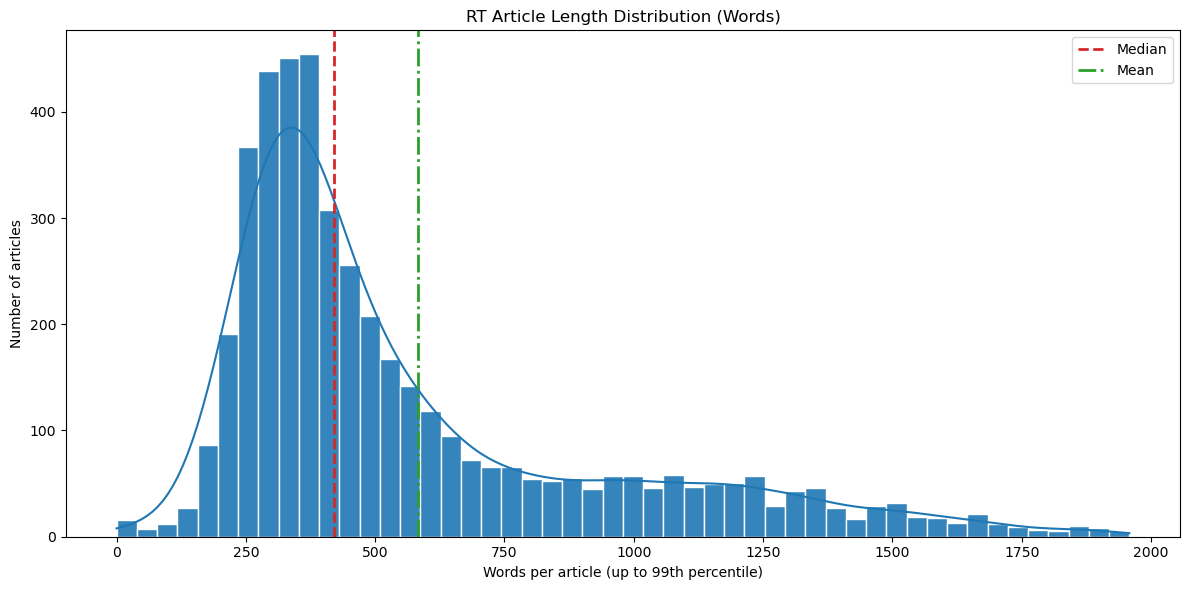

In [13]:
# Plot article length distribution, excluding extreme outliers above the 99th percentile
q99 = df_clean["article_length_words"].quantile(0.99)
length_plot = df_clean[df_clean["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(df_clean["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(df_clean["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("RT Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
# Compute daily article counts and 7-day rolling average
daily_counts = (
    df_clean.set_index("Date")
    .resample("D")
    .size()
    .rename("articles")
    .reset_index()
)
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

daily_counts.head()


,Date,articles,rolling_7d
0,2025-08-01,15,15.000000
1,2025-08-02,28,21.500000
2,2025-08-03,24,22.333333
3,2025-08-04,26,23.250000
4,2025-08-05,32,25.000000


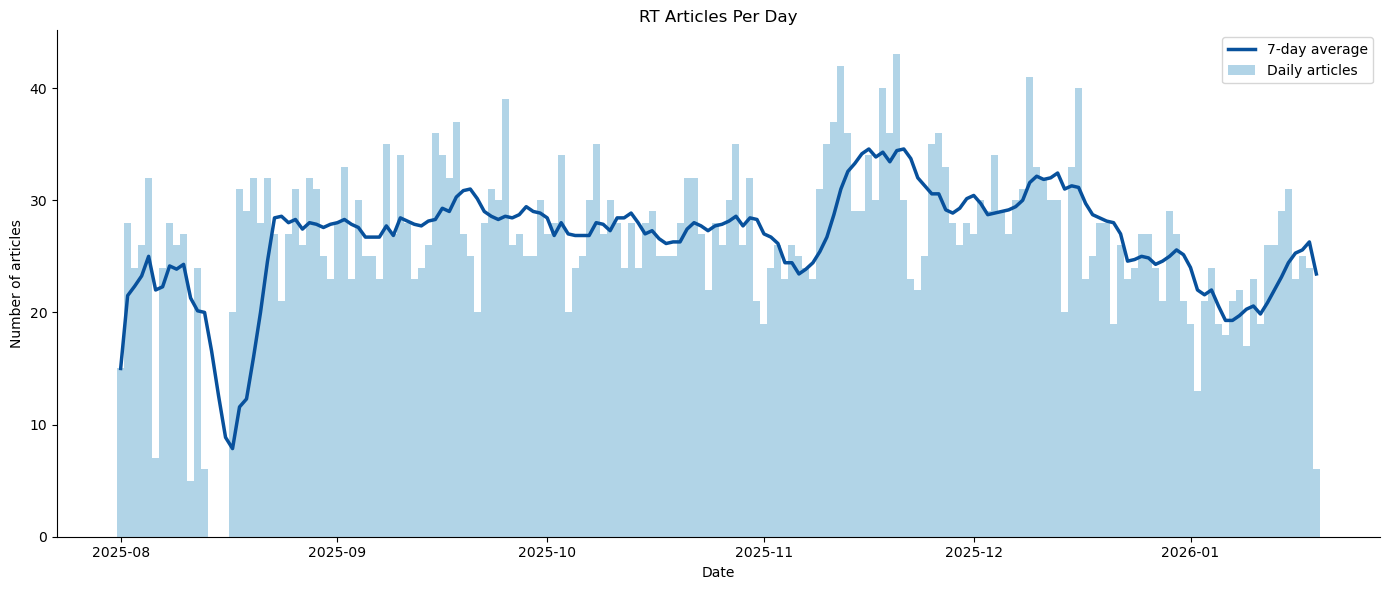

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("RT Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


## BERTopic old 


In [16]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


In [17]:
from BERTopic.bertopic_pipeline import run_bertopic_pipeline


In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4570 entries, 0 to 4569
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  4570 non-null   datetime64[ns]
 1   Category              4570 non-null   object        
 2   Title                 4570 non-null   object        
 3   Summary               4567 non-null   object        
 4   Text                  4570 non-null   object        
 5   URL                   4570 non-null   object        
 6   source                4570 non-null   object        
 7   source_file           4570 non-null   object        
 8   article_length_words  4570 non-null   int64         
 9   article_length_chars  4570 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 392.7+ KB


In [22]:
from BERTopic.bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)


2 0.9


In [19]:
from pathlib import Path
import sys

# from ".../data preprocessing" -> project root ".../Thesis"
PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)


cwd: /Users/gretawette/Documents/Thesis/data preprocessing
project root added: /Users/gretawette/Documents/Thesis


In [21]:
# from BERTopic.bertopic_pipeline import prepare_documents
# from BERTopic.bertopic_config import BERTopicConfig, title_config

# cfg = BERTopicConfig(min_df=5, max_df=0.88)   # or whatever you test
# prep = prepare_documents(df_clean, text_col="Text", config=cfg, id_col="URL")
# n = len(prep)

# print("prepared docs:", n)
# print("min_df:", cfg.min_df, "max_df:", cfg.max_df)
# print("max_df_docs:", int(cfg.max_df * n) if isinstance(cfg.max_df, float) else cfg.max_df)


In [22]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 16:18:20,159 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-08 16:18:59,195 - BERTopic - Embedding - Completed ✓
2026-03-08 16:18:59,197 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 16:19:14,710 - BERTopic - Dimensionality - Completed ✓
2026-03-08 16:19:14,718 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 16:19:14,837 - BERTopic - Cluster - Completed ✓
2026-03-08 16:19:14,845 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 16:19:21,750 - BERTopic - Representation - Completed ✓


In [23]:
topic_info = result["topic_info"]
topic_info.head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_moldawien_usaid_power_lexus,"[moldawien, usaid, power, lexus, sandu, wowan lexus, wowan, ehemalige, abgeschobene bürger, eswatini]","[Eswatini hat von den USA 5,1 Millionen US-Dollar oder umgerechnet 4,4 Millionen Euro erhalten, um aus dem nordamerikanischen Land abgeschobene Bürger von D..."
1,0,4121,0_über_so_wurde_noch,"[über, so, wurde, noch, war, man, jahr, nato, erklärte, putin]","[Von Andrei Restschikow Am Donnerstag, dem 2. Oktober, hat der russische Präsident Wladimir Putin an der Plenarsitzung der 22. Jahrestagung des Internationa..."
2,1,318,1_israel_gaza_hamas_iran,"[israel, gaza, hamas, iran, israelischen, al, israelische, netanjahu, gazastreifen, israels]",[Von Susan Bonath Der Al-Jazeera-Journalist Anas al-Sharif dokumentierte 22 Monate lang Israels Gräuel im Gazastreifen. Den Tätern war der 28-Jährige schon ...
3,2,55,2_indien_öl_indische_delhi,"[indien, öl, indische, delhi, neu delhi, indiens, neu, indischen, modi, russischem]",[Von Manish Vaid Während die US-Rhetorik gegen Indien immer offener erpresserisch wird und Spitzenpolitiker Neu-Delhi vor den Konsequenzen seines Energiehan...
4,3,34,3_grönland_dänemark_grönlands_insel,"[grönland, dänemark, grönlands, insel, dänische, nato, arktis, trumps, über, kopenhagen]","[Der dänische Botschafter in den USA, Jesper Møller Sørensen, hat aufgrund eines provokanten Beitrags auf X dazu aufgerufen, die territoriale Integrität sei..."
5,4,27,4_kirk_charlie_charlie kirk_mord,"[kirk, charlie, charlie kirk, mord, wurde, kirks, utah, robinson, war, so]","[US-Präsident Donald Trump, Mitglieder seines Kabinetts und sonstige Persönlichkeiten des öffentlichen Lebens nahmen an der Gedenkzeremonie für den konserva..."


In [24]:
#pip install gensim

In [25]:
import sys
!{sys.executable} -m pip install "scipy<1.13" "gensim==4.3.2"



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [26]:
print(run_bertopic_pipeline.__module__)


BERTopic.bertopic_pipeline


In [27]:
# pip install gensim
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.1552144428732983,
 'topic_diversity': 0.9,
 'num_topics': 5,
 'top_k': 10}

TO DO for tomorrow

In [28]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=10),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 16:19:39,649 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-08 16:20:19,812 - BERTopic - Embedding - Completed ✓
2026-03-08 16:20:19,814 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 16:20:27,827 - BERTopic - Dimensionality - Completed ✓
2026-03-08 16:20:27,830 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 16:20:27,970 - BERTopic - Cluster - Completed ✓
2026-03-08 16:20:27,984 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 16:20:31,213 - BERTopic - Representation - Completed ✓


In [29]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1921,-1_russischen_ukrainischen_nato_präsident,"[russischen, ukrainischen, nato, präsident, europa, putin, afd, europäischen, moskau, ukrainische]",[Von Boris Dscherelijewski Russlands Einrichtungen der Energieinfrastruktur – von Ölraffinerien bis hin zu Kraft- und Umspannwerken – sind zu den vorrangige...
1,0,318,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels]",[Das Abkommen zwischen der Hamas und Israel sieht einen vorläufigen Rückzug Israels aus dem Gazastreifen und die Freilassung von fast 2.000 palästinensische...
2,1,166,1_venezuela_maduro_venezuelas_karibik,"[venezuela, maduro, venezuelas, karibik, venezolanischen, venezolanische, caracas, nicolás maduro, nicolás, präsident]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
3,2,129,2_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, xi, chinesischen, chinesische, japan, zölle, beziehungen]","[Von Georgi Bowt Das Treffen zwischen US-Präsident Donald Trump und dem chinesischen Staatspräsidenten Xi Jinping in Südkorea führte nicht zu einem Frieden,..."
4,3,129,3_treffen_putin_selenskij_präsident,"[treffen, putin, selenskij, präsident, präsidenten, trumps, wladimir, us präsident, kiew, donald]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
5,4,102,4_nato_europa_russischen_russlands,"[nato, europa, russischen, russlands, putin, moskau, estland, russen, finnland, estnischen]","[Von Pjotr Akopow Erst vor einer Woche gab Wladimir Putin wörtlich zu verstehen: Falls Europa gegen Russland kämpfen will, sei Russland bereit – und am Donn..."
6,5,95,5_vermögenswerte_milliarden_milliarden euro_euro,"[vermögenswerte, milliarden, milliarden euro, euro, belgien, euroclear, eingefrorenen, gelder, russischen, geld]","[Laut Plänen der EU-Kommission soll Deutschland zum größten Garantiegeber eines sogenannten ""Reparationskredits"" für die Ukraine werden. Dieser soll über ei..."
7,6,80,6_drohnen_luftraum_nato_polen,"[drohnen, luftraum, nato, polen, drohne, polnischen, russischen, flugzeuge, vorfall, polnische]",[Von Boris Dscherelijewski In den vergangenen vier Jahren wurden Russland und die Ukraine zu führenden Mächten im Hinblick auf Kampfeinsatz und Bekämpfung v...
8,7,69,7_film_russischen_intervision_theater,"[film, russischen, intervision, theater, wettbewerb, künstler, puschkin, putin, dw, journalisten]","[In der Nacht zum 21. September 2025 ging im Moskauer Hauptstadtstadion ""Live Arena"" der internationale Musikwettbewerb ""Intervision"" zu Ende. Wie das Organ..."
9,8,61,8_euro_deutsche_industrie_wirtschaft,"[euro, deutsche, industrie, wirtschaft, zahl, zahlen, armut, studie, quartal, bundesregierung]","[Der Paritätische hat eine Berechnung veröffentlicht, die eigentlich lange überfällig war: Wie viele Menschen in Deutschland sind arm, wenn man betrachtet, ..."


In [30]:



# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.08372089525076563,
 'topic_diversity': 0.7835616438356164,
 'num_topics': 73,
 'top_k': 10}

In [31]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 16:20:49,841 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-08 16:21:31,220 - BERTopic - Embedding - Completed ✓
2026-03-08 16:21:31,224 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 16:21:39,095 - BERTopic - Dimensionality - Completed ✓
2026-03-08 16:21:39,099 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 16:21:39,238 - BERTopic - Cluster - Completed ✓
2026-03-08 16:21:39,251 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 16:21:43,102 - BERTopic - Representation - Completed ✓


In [32]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2022,-1_ukrainischen_nato_europa_putin,"[ukrainischen, nato, europa, putin, europäischen, ukrainische, afd, russlands, kiew, selenskij]",[Von Jewgeni Posdnjakow Die Staats- und Regierungschefs der EU und Großbritanniens haben eine gemeinsame Erklärung zu den Verhandlungen zwischen Wladimir Pu...
1,0,318,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels]",[Nach ihrer gestrigen dreistündigen Unterredung im Weißen Haus gaben US-Präsident Donald Trump und der israelische Premierminister Benjamin Netanjahu eine P...
2,1,166,1_venezuela_maduro_venezuelas_karibik,"[venezuela, maduro, venezuelas, karibik, venezolanischen, venezolanische, caracas, nicolás, nicolás maduro, washington]",[Die Vereinigten Staaten bauen die militärische Drohkulisse gegenüber Venezuela weiter auf. Laut CNN erwägt US-Präsident Donald Trump Angriffe auf venezolan...
3,2,129,2_putin_selenskij_präsidenten_trumps,"[putin, selenskij, präsidenten, trumps, wladimir, kiew, us präsident, washington, nato, verhandlungen]","[US-Präsident Donald Trump hat sich für die Organisation eines dreiseitigen Gipfels mit Wladimir Putin und Wladimir Selenskij ausgesprochen, um die Ukraine-..."
4,3,129,3_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, xi, chinesischen, chinesische, japan, zölle, beziehungen]","[Der chinesische Präsident Xi Jinping, der wiederholt erklärt hat, dass die Wiedervereinigung mit Taiwan ""unvermeidlich"" sei, bekräftigte diese Ansicht in s..."
5,4,102,4_nato_europa_russlands_putin,"[nato, europa, russlands, putin, estland, russen, finnland, europäischen, estnischen, länder]","[Von Pjotr Akopow Erst vor einer Woche gab Wladimir Putin wörtlich zu verstehen: Falls Europa gegen Russland kämpfen will, sei Russland bereit – und am Donn..."
6,5,95,5_vermögenswerte_milliarden_milliarden euro_euro,"[vermögenswerte, milliarden, milliarden euro, euro, belgien, euroclear, eingefrorenen, gelder, geld, kommission]",[Von Achim Detjen Auf dem am Donnerstag beginnenden zweitägigen Gipfel der EU-Staats- und Regierungschefs in Brüssel steht die Finanzierung des Ukraine-Krie...
7,6,80,6_drohnen_nato_luftraum_polen,"[drohnen, nato, luftraum, polen, drohne, polnischen, flugzeuge, vorfall, polnische, russische drohnen]",[Von Boris Dscherelijewski In den vergangenen vier Jahren wurden Russland und die Ukraine zu führenden Mächten im Hinblick auf Kampfeinsatz und Bekämpfung v...
8,7,69,7_film_intervision_theater_wettbewerb,"[film, intervision, theater, wettbewerb, künstler, puschkin, putin, journalisten, propaganda, dw]","[In der Nacht zum 21. September 2025 ging im Moskauer Hauptstadtstadion ""Live Arena"" der internationale Musikwettbewerb ""Intervision"" zu Ende. Wie das Organ..."
9,8,61,8_euro_deutsche_industrie_wirtschaft,"[euro, deutsche, industrie, wirtschaft, zahl, zahlen, armut, studie, quartal, bundesregierung]","[Der Paritätische hat eine Berechnung veröffentlicht, die eigentlich lange überfällig war: Wie viele Menschen in Deutschland sind arm, wenn man betrachtet, ..."


In [33]:



# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.08221797249771073,
 'topic_diversity': 0.7728813559322034,
 'num_topics': 59,
 'top_k': 10}

In [34]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15, hdbscan_min_samples=4),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 16:22:06,861 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-08 16:23:04,235 - BERTopic - Embedding - Completed ✓
2026-03-08 16:23:04,342 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 16:23:15,168 - BERTopic - Dimensionality - Completed ✓
2026-03-08 16:23:15,178 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 16:23:15,356 - BERTopic - Cluster - Completed ✓
2026-03-08 16:23:15,384 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 16:23:19,554 - BERTopic - Representation - Completed ✓


In [35]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1647,-1_ukrainischen_nato_putin_ukrainische,"[ukrainischen, nato, putin, ukrainische, kiew, selenskij, milliarden, china, euro, afd]","[Von Platon Gontscharow Wie erklärt man den Widerspruch, dass die ukrainische Armee im Westen in den Medien und von Militäranalysten überschwänglich gelobt ..."
1,0,318,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels]",[Nach ihrer gestrigen dreistündigen Unterredung im Weißen Haus gaben US-Präsident Donald Trump und der israelische Premierminister Benjamin Netanjahu eine P...
2,1,152,1_nato_putin_estland_russen,"[nato, putin, estland, russen, estnischen, finnland, konflikt, westlichen, bedrohung, wladimir]","[Von Kirill Strelnikow Äußerungen, die Russlands Präsident Wladimir Wladimirowitsch Putin auf der jüngsten Sitzung des Sicherheitsrats des Landes machte, kö..."
3,2,142,2_selenskij_putin_präsidenten_wladimir,"[selenskij, putin, präsidenten, wladimir, kiew, us präsident, trumps, washington, nato, wladimir putin]","[US-Präsident Donald Trump hat sich für die Organisation eines dreiseitigen Gipfels mit Wladimir Putin und Wladimir Selenskij ausgesprochen, um die Ukraine-..."
4,3,111,3_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesische, chinesischen, japan, xi, zölle, takaichi]",[Von Dmitri Bawyrin Die Armee der Volksrepublik China hat bereits mehrfach das Regierungsviertel der taiwanesischen Hauptstadt Taipeh gestürmt und die Kontr...
5,4,110,4_drohnen_flugzeuge_flugzeug_luftraum,"[drohnen, flugzeuge, flugzeug, luftraum, nato, polen, drohne, polnischen, vorfall, gps]",[Von Boris Dscherelijewski In den vergangenen vier Jahren wurden Russland und die Ukraine zu führenden Mächten im Hinblick auf Kampfeinsatz und Bekämpfung v...
6,5,99,5_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, caracas, nicolás maduro, nicolás, venezolanische, maduros, rodríguez]","[Von Aljona Sadoroschnaja Die USA haben gegen den venezolanischen Präsidenten Nicolás Maduro und seine Ehefrau Anklage wegen ""Drogenterrorismus"" erhoben. Wi..."
7,6,76,6_us dollar_dollar_barrel_tonnen,"[us dollar, dollar, barrel, tonnen, pro, millionen tonnen, pro barrel, opec, markt, dollar pro]","[Von Olga Samofalowa Da es auf dem Markt zu viel Erdöl gibt, sinken die Preise weiter. Diese Woche nähern sie sich der Marke von 60 US-Dollar pro Barrel. Di..."
8,7,76,7_kiew_selenskij_putin_wladimir,"[kiew, selenskij, putin, wladimir, ukrainischen, konflikts, plan, präsidenten, nato, verhandlungen]","[Von Jewgeni Posdnjakow Der Impuls zur Beilegung des Konflikts in der Ukraine, der durch das Treffen zwischen Wladimir Putin und Donald Trump in Alaska ausg..."
9,8,74,8_orbán_ungarn_ungarische_brüssel,"[orbán, ungarn, ungarische, brüssel, serbien, viktor, union, beitritt, viktor orbán, moldawien]","[Während eines Besuchs in Rom erklärte der ungarische Ministerpräsident Viktor Orbán gegenüber der italienischen Zeitung La Repubblica, er werde nächste Woc..."


In [36]:


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.07120940969974214,
 'topic_diversity': 0.7727272727272727,
 'num_topics': 66,
 'top_k': 10}

In [51]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15, hdbscan_min_samples=3, max_df=0.85),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 17:22:53,653 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-08 17:24:00,199 - BERTopic - Embedding - Completed ✓
2026-03-08 17:24:00,209 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 17:24:09,032 - BERTopic - Dimensionality - Completed ✓
2026-03-08 17:24:09,050 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 17:24:09,329 - BERTopic - Cluster - Completed ✓
2026-03-08 17:24:09,390 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 17:24:17,951 - BERTopic - Representation - Completed ✓


In [52]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1550,-1_ukrainischen_nato_china_ukrainische,"[ukrainischen, nato, china, ukrainische, selenskij, euro, kiew, soldaten, polen, merz]","[""Er hat doch Napoleon gespielt, der Selenskij, nicht wahr? (...) Dieser Napoleon wird bald Geschichte sein"", sagte ein Mann mit lockigem grauem Haar und st..."
1,0,212,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, gazastreifen, israelische, netanjahu, israels, geiseln, al]","[Der neuerliche Angriff der israelischen Armee auf Gaza findet vor einem veränderten Hintergrund statt. Zwar hat US-Außenminister Marco Rubio, der gerade er..."
2,1,189,1_nato_russen_estland_kallas,"[nato, russen, estland, kallas, estnischen, finnland, bedrohung, wladimir putin, gegen russland, grenze]","[Von Anton Gentzen Die grüne Bundestagsabgeordnete Sara Nanni, sicherheitspolitische Sprecherin ihrer Fraktion und durch militante antirussische Äußerungen ..."
3,2,153,2_selenskij_us präsident_trumps_kiew,"[selenskij, us präsident, trumps, kiew, wladimir putin, nato, weißen, alaska, verhandlungen, ukrainischen]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
4,3,114,3_drohnen_flugzeuge_flugzeug_luftraum,"[drohnen, flugzeuge, flugzeug, luftraum, polen, nato, drohne, polnischen, vorfall, flughafen]",[Von Boris Dscherelijewski In den vergangenen vier Jahren wurden Russland und die Ukraine zu führenden Mächten im Hinblick auf Kampfeinsatz und Bekämpfung v...
5,4,104,4_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, caracas, nicolás maduro, nicolás, venezolanische, maduros, rodríguez]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
6,5,100,5_vermögenswerte_milliarden euro_euro_belgien,"[vermögenswerte, milliarden euro, euro, belgien, euroclear, gelder, eingefrorenen, kommission, russischer vermögenswerte, de wever]","[Laut Plänen der EU-Kommission soll Deutschland zum größten Garantiegeber eines sogenannten ""Reparationskredits"" für die Ukraine werden. Dieser soll über ei..."
7,6,89,6_zusammenarbeit_witkoff_beziehungen_wladimir putin,"[zusammenarbeit, witkoff, beziehungen, wladimir putin, gespräche, gus, konflikts, lawrow, dialog, verhandlungen]","[Im Oktober 2025 wird das Nationale Zentrum ""Rossija"" in Moskau eine der größten internationalen Veranstaltungen in den Bereichen Zukunftsforschung, Wissens..."
8,7,89,7_selenskij_kiew_ukrainischen_konflikts,"[selenskij, kiew, ukrainischen, konflikts, plan, frieden, nato, friedensplan, verhandlungen, für ukraine]","[Ein von den USA vorgeschlagener Friedensplan für den Russland-Ukraine-Konflikt, der demnach gemeinsam mit Moskau entwickelt wurde, erfordert laut Berichten..."
9,8,73,8_nord stream_stream_nord_polen,"[nord stream, stream, nord, polen, auslieferung, ukrainischen, festgenommen, pipelines, polnischen, verdächtigen]","[Nach Informationen der polnischen Zeitung Wiadomosci hat Deutschland die polnische Staatsanwaltschaft gebeten, die gegen in Polen festgenommenen mutmaßlich..."


In [54]:
# Save topics from the current BERTopic run
topics_out = PROJECT_ROOT / "BERTopic" / "outputs" / "rt_topics_current_run.csv"
topics_out.parent.mkdir(parents=True, exist_ok=True)

result["topic_info"].to_csv(topics_out, index=False, encoding="utf-8-sig")
print(f"Saved topic table to: {topics_out}")

Saved topic table to: /Users/gretawette/Documents/Thesis/BERTopic/outputs/rt_topics_current_run.csv


In [53]:
# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.06962479532012804,
 'topic_diversity': 0.7797297297297298,
 'num_topics': 74,
 'top_k': 10}

## Best Run

In [23]:
# 1) BERTopic on full article text
result_full_text_rt = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15, hdbscan_min_samples=3, max_df=0.85, umap_n_neighbors=40, umap_min_dist=0.05,),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result_rt = result_full_text_rt

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 19:01:34,274 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-08 19:02:12,566 - BERTopic - Embedding - Completed ✓
2026-03-08 19:02:12,567 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 19:02:28,572 - BERTopic - Dimensionality - Completed ✓
2026-03-08 19:02:28,574 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 19:02:28,688 - BERTopic - Cluster - Completed ✓
2026-03-08 19:02:28,694 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 19:02:31,545 - BERTopic - Representation - Completed ✓


In [24]:
topic_info_rt = result_rt["topic_info"]
topic_info_rt.head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1676,-1_putin_euro_milliarden_kiew,"[putin, euro, milliarden, kiew, merz, china, ukrainische, polen, selenskij, europäische]","[Von Pierre Lévy Die europäischen Gipfeltreffen folgen aufeinander und ähneln sich. Gleiche Akteure, gleiches Szenario, gleiche Dialoge, gleiche Streitigkei..."
1,0,322,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels]",[Nach ihrer gestrigen dreistündigen Unterredung im Weißen Haus gaben US-Präsident Donald Trump und der israelische Premierminister Benjamin Netanjahu eine P...
2,1,232,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás maduro, nicolás, washington]",[Die Vereinigten Staaten bauen die militärische Drohkulisse gegenüber Venezuela weiter auf. Laut CNN erwägt US-Präsident Donald Trump Angriffe auf venezolan...
3,2,190,2_putin_selenskij_trumps_washington,"[putin, selenskij, trumps, washington, kiew, wladimir putin, verhandlungen, witkoff, alaska, konflikts]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
4,3,134,3_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesischen, chinesische, xi, japan, zölle, xi jinping]","[Von Rafael Fachrutdinow Japan werde eine ""vernichtende Niederlage"" erleiden, wenn es sich dazu entschließe, in der Taiwan-Frage militärische Gewalt anzuwen..."
5,4,130,4_afd_bsw_partei_spd,"[afd, bsw, partei, spd, cdu, habeck, grünen, kandidaten, weidel, stimmen]","[Am Sonntag erfolgten in knapp 150 Kreisen und Städten Nordrhein-Westfalens Stichwahlen um die Posten von Landrats-, Bürgermeister- und Oberbürgermeister-Äm..."
6,5,115,5_drohnen_flugzeuge_flugzeug_luftraum,"[drohnen, flugzeuge, flugzeug, luftraum, polen, drohne, polnischen, luft, vorfall, flughafen]",[Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren in der Nacht mindestens drei russische Drohnen von NATO- und polnischen Flugzeugen im pol...
7,6,114,6_dollar_us dollar_gold_pro,"[dollar, us dollar, gold, pro, tonnen, dollar pro, barrel, zentralbank, millionen tonnen, markt]","[Von Rainer Rupp Über Jahrzehnte hinweg hat der Westen, vor allem die US-Zentralbank Fed, den Marktpreis für Gold als einzig wahre Messlatte für die Inflati..."
8,7,94,7_vermögenswerte_milliarden_milliarden euro_euro,"[vermögenswerte, milliarden, milliarden euro, euro, belgien, euroclear, gelder, eingefrorenen, kommission, russischer vermögenswerte]",[Von Achim Detjen Auf dem am Donnerstag beginnenden zweitägigen Gipfel der EU-Staats- und Regierungschefs in Brüssel steht die Finanzierung des Ukraine-Krie...
9,8,72,8_kommission_leyen_schweizer_schweiz,"[kommission, leyen, schweizer, schweiz, daten, digitale, ki, brüssel, ursula, plattformen]",[Von Gert Ewen Ungar EU-Kommissionspräsidentin Ursula von der Leyen plant die Schaffung eines eigenen EU-Geheimdienstes. Dieser soll ihr direkt unterstellt ...


In [ ]:
# # In 01_RT.ipynb
# rt_model = result_rt["topic_model"]
# rt_model.save(
#     "/Users/gretawette/Documents/Thesis/BERTopic/outputs/rt_model",
#     serialization="safetensors",   # more robust than pickle
#     save_ctfidf=True,
#     save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
# )


In [ ]:
# # In 01_RT.ipynb (after result_full_text_rt is created)
# import joblib
# from pathlib import Path

# PROJECT_ROOT = Path.cwd().resolve().parent
# result_rt = result_full_text_rt
# joblib.dump(result_rt, PROJECT_ROOT / "BERTopic" / "outputs" / "result_rt.joblib")


['/Users/gretawette/Documents/Thesis/BERTopic/outputs/result_rt.joblib']

In [25]:
# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result_rt["topic_model"], top_k=10)
metrics

NameError: name 'evaluate_bertopic' is not defined

In [ ]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=20, hdbscan_min_samples=5, max_df=0.85, umap_n_neighbors=45, umap_min_dist=0.05,),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 15:34:02,999 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-08 15:35:29,681 - BERTopic - Embedding - Completed ✓
2026-03-08 15:35:29,703 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 15:35:41,844 - BERTopic - Dimensionality - Completed ✓
2026-03-08 15:35:41,861 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 15:35:42,147 - BERTopic - Cluster - Completed ✓
2026-03-08 15:35:42,228 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 15:35:50,420 - BERTopic - Representation - Completed ✓


In [ ]:
topic_info = result["topic_info"]
topic_info.head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1821,-1_ukrainische_china_selenskij_merz,"[ukrainische, china, selenskij, merz, polen, soldaten, armee, streitkräfte, russen, afd]",[Von Tarik Cyril Amar Bundeskanzler Friedrich Merz hat für Aufsehen in den Medien gesorgt und innerhalb seiner eigenen Regierungskoalition mit den Sozialdem...
1,0,313,0_israel_gaza_hamas_iran,"[israel, gaza, hamas, iran, israelischen, al, israelische, gazastreifen, netanjahu, israels]","[Das israelische Militär hat am Sonntag einen Angriff auf Gaza gestartet, wie israelische Medien und Einwohner berichten. Damit schwinden die Hoffnungen, da..."
2,1,231,1_selenskij_trumps_konflikts_alaska,"[selenskij, trumps, konflikts, alaska, witkoff, gipfel, weißen, frieden, russischen präsidenten, treffens]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
3,2,231,2_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás, nicolás maduro, drogen]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
4,3,227,3_afd_spd_cdu_bsw,"[afd, spd, cdu, bsw, stimmen, grünen, demokratie, wahl, parteien, weidel]","[In einer von den Unions- und SPD-Fraktionen beantragten ""Aktuellen Stunde"" mit dem laut Bundestagswebseite wörtlichen Titel ""Auswirkungen des Verhältnisses..."
5,4,130,4_drohnen_flugzeuge_flugzeug_luftraum,"[drohnen, flugzeuge, flugzeug, luftraum, polen, drohne, luft, polnischen, systeme, burewestnik]","[Das Eindringen unbemannter, nicht identifizierter Flugzeuge hat in den vergangenen Wochen in Europa für Alarm gesorgt, und die NATO-Verbündeten diskutieren..."
6,5,123,5_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesischen, chinesische, xi, japan, zölle, insel]","[Der chinesische Präsident Xi Jinping, der wiederholt erklärt hat, dass die Wiedervereinigung mit Taiwan ""unvermeidlich"" sei, bekräftigte diese Ansicht in s..."
7,6,116,6_estland_russen_finnland_estnischen,"[estland, russen, finnland, estnischen, bedrohung, gegen russland, kallas, finnischen, grenze, rutte]","[Von Andrei Restschikow Am Donnerstag, dem 2. Oktober, hat der russische Präsident Wladimir Putin an der Plenarsitzung der 22. Jahrestagung des Internationa..."
8,7,108,7_vermögenswerte_milliarden euro_belgien_euroclear,"[vermögenswerte, milliarden euro, belgien, euroclear, gelder, eingefrorenen, kommission, russischer vermögenswerte, für ukraine, zentralbank]","[Laut Plänen der EU-Kommission soll Deutschland zum größten Garantiegeber eines sogenannten ""Reparationskredits"" für die Ukraine werden. Dieser soll über ei..."
9,8,91,8_polizei_verletzt_täter_jährige,"[polizei, verletzt, täter, jährige, brand, ermittlungen, verletzten, messer, feuerwehr, berliner]",[Für den frühen Samstagabend und den frühen Sonntagmorgen finden sich gleich zwei Polizeimeldungen zu eskalierenden Gewaltsituationen unter Einsatz von Mess...


In [ ]:
# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.07744111832075425,
 'topic_diversity': 0.8875,
 'num_topics': 40,
 'top_k': 10}

In [47]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=20, hdbscan_min_samples=5, max_df=0.85, umap_n_neighbors=45, umap_min_dist=0.05,ngram_range=(1, 3)),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 16:44:29,716 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-08 16:46:15,857 - BERTopic - Embedding - Completed ✓
2026-03-08 16:46:15,874 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 16:46:26,907 - BERTopic - Dimensionality - Completed ✓
2026-03-08 16:46:26,923 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 16:46:27,148 - BERTopic - Cluster - Completed ✓
2026-03-08 16:46:27,166 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 16:46:38,232 - BERTopic - Representation - Completed ✓


In [48]:
topic_info = result["topic_info"]
topic_info.head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1821,-1_ukrainische_china_selenskij_merz,"[ukrainische, china, selenskij, merz, polen, soldaten, armee, streitkräfte, russen, afd]",[Von Tarik Cyril Amar Bundeskanzler Friedrich Merz hat für Aufsehen in den Medien gesorgt und innerhalb seiner eigenen Regierungskoalition mit den Sozialdem...
1,0,313,0_israel_gaza_hamas_iran,"[israel, gaza, hamas, iran, israelischen, al, israelische, gazastreifen, netanjahu, israels]",[Nach ihrer gestrigen dreistündigen Unterredung im Weißen Haus gaben US-Präsident Donald Trump und der israelische Premierminister Benjamin Netanjahu eine P...
2,1,231,1_selenskij_trumps_konflikts_alaska,"[selenskij, trumps, konflikts, alaska, witkoff, gipfel, weißen, frieden, russischen präsidenten, treffens]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
3,2,231,2_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás, nicolás maduro, drogen]","[Von Rainer Rupp US-Präsident Trump hat in den vergangenen Wochen die Karibik, die Sehnsucht-Region vieler Urlauber aus dem Norden, in ein brandgefährliches..."
4,3,227,3_afd_spd_cdu_bsw,"[afd, spd, cdu, bsw, stimmen, grünen, demokratie, wahl, parteien, weidel]","[In einer von den Unions- und SPD-Fraktionen beantragten ""Aktuellen Stunde"" mit dem laut Bundestagswebseite wörtlichen Titel ""Auswirkungen des Verhältnisses..."
5,4,130,4_drohnen_flugzeuge_flugzeug_luftraum,"[drohnen, flugzeuge, flugzeug, luftraum, polen, drohne, luft, polnischen, systeme, raketen]","[Das Eindringen unbemannter, nicht identifizierter Flugzeuge hat in den vergangenen Wochen in Europa für Alarm gesorgt, und die NATO-Verbündeten diskutieren..."
6,5,123,5_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesischen, chinesische, xi, japan, zölle, insel]","[Von Rafael Fachrutdinow Japan werde eine ""vernichtende Niederlage"" erleiden, wenn es sich dazu entschließe, in der Taiwan-Frage militärische Gewalt anzuwen..."
7,6,116,6_estland_russen_finnland_estnischen,"[estland, russen, finnland, estnischen, bedrohung, gegen russland, kallas, grenze, finnischen, rutte]","[Von Kirill Strelnikow Äußerungen, die Russlands Präsident Wladimir Wladimirowitsch Putin auf der jüngsten Sitzung des Sicherheitsrats des Landes machte, kö..."
8,7,108,7_vermögenswerte_milliarden euro_belgien_euroclear,"[vermögenswerte, milliarden euro, belgien, euroclear, gelder, eingefrorenen, kommission, russischer vermögenswerte, für ukraine, zentralbank]","[Laut Plänen der EU-Kommission soll Deutschland zum größten Garantiegeber eines sogenannten ""Reparationskredits"" für die Ukraine werden. Dieser soll über ei..."
9,8,91,8_polizei_verletzt_täter_jährige,"[polizei, verletzt, täter, jährige, ermittlungen, brand, verletzten, messer, feuerwehr, berliner]",[Für den frühen Samstagabend und den frühen Sonntagmorgen finden sich gleich zwei Polizeimeldungen zu eskalierenden Gewaltsituationen unter Einsatz von Mess...


In [49]:
# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.08224319475102122,
 'topic_diversity': 0.8825,
 'num_topics': 40,
 'top_k': 10}

In [50]:
#Intertopic distance map
result["topic_model"].visualize_topics()

## BERTopic on Titles

In [38]:
# make sure project root is importable (if notebook runs from "data preprocessing/")
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from BERTopic.bertopic_pipeline import run_bertopic_pipeline
from BERTopic.bertopic_config import title_config

# BERTopic on titles
config_title = title_config()

result_title = run_bertopic_pipeline(
    df=df_clean,
    text_col="Title",   # switch from Text to Title
    config=config_title,
    id_col="URL",
    source_name="RT_de",
)

# optional: keep downstream cells using `result`
result = result_title

topic_info = result_title["topic_info"]
topic_info.head(20)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-08 16:24:26,398 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-08 16:26:06,849 - BERTopic - Embedding - Completed ✓
2026-03-08 16:26:06,867 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-08 16:26:17,566 - BERTopic - Dimensionality - Completed ✓
2026-03-08 16:26:17,579 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-08 16:26:17,814 - BERTopic - Cluster - Completed ✓
2026-03-08 16:26:17,842 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-08 16:26:18,109 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1365,-1_russland_ukraine_us_moskau,"[russland, ukraine, us, moskau, usa, über, russische, selenskij, trump, russlands]","[Polens Ex-Präsident: Selenskijs Traum ist ein Krieg zwischen Russland und der NATO, Lawrow: Russland ist bereit, NATO und EU Sicherheitsgarantien zu geben,..."
1,0,271,0_israel_gaza_netanjahu_israels,"[israel, gaza, netanjahu, israels, hamas, katar, gazastreifen, idf, palästina, iran]","[Nach neuen Gaza-Plänen von Netanjahu: Bundesregierung stoppt Waffenlieferungen nach Israel, Israel droht mit der Zerstörung von Gaza-Stadt, Trotz Waffenruh..."
2,1,237,1_ukraine_nato_ukrainische_kiew,"[ukraine, nato, ukrainische, kiew, soldaten, ukrainischen, selenskij, ukrainer, ukrainischer, kiews]","[Die Schwarze Erde der Ukraine und die verschwiegene Realität in einem ruinierten Land (Teil 1), Die Schwarze Erde der Ukraine und die verschwiegene Realitä..."
3,2,211,2_venezuela_maduro_venezuelas_us,"[venezuela, maduro, venezuelas, us, usa, karibik, gegen venezuela, trump, nigeria, gegen]","[Medien: Drei US-Szenarien für Angriffskrieg gegen Venezuela – Maduro verabschiedet Widerstandsplan, Donald Trump schließt Militärschlag gegen Venezuela nic..."
4,3,200,3_putin_putins_putin trump_trump,"[putin, putins, putin trump, trump, gipfel, treffen, trump putin, selenskij, kreml, budapest]","[Nächste Woche Putin-Trump-Gipfel in Alaska?, Kreml schließt Treffen zwischen Putin und Selenskij nicht aus, Treffen von Putin, Trump und Selenskij: Tusk ge..."
5,4,139,4_china_taiwan_japan_usa,"[china, taiwan, japan, usa, chinas, erden, peking, china will, trump, xi]","[Taiwan-Frage spaltet China und Japan: Peking droht Tokio mit Konsequenzen, Macron besucht China: Europa im Spannungsfeld zwischen USA und China, Eskalation..."
6,5,128,5_drohnen_drohnenangriff_drohne_polen,"[drohnen, drohnenangriff, drohne, polen, russische drohnen, russische, drohnen über, testet, dvrk, ukrainischer]","[Russische Drohnen über Ostdeutschland: Moskau weist Vorwürfe zurück, Wer schickte russische Drohnen nach Polen – und warum?, Die GPS-Lüge und Drohnen, Droh..."
7,6,108,6_afd_spd_cdu_brandenburg,"[afd, spd, cdu, brandenburg, bsw, umfrage, nrw, koalition, für afd, demokratie]","[Umfragehammer für AfD: Partei erreicht bei INSA-Umfrage Allzeithoch mit 27 Prozent, INSA-Umfrage: AfD erreicht Rekordwert – Union fällt auf unter 25 Prozen..."
8,7,86,7_ukraine_eu_orbán_milliarden,"[ukraine, eu, orbán, milliarden, für ukraine, kiew, euro, frieden, frieden ukraine, europa]","[Merz gegen De Wever: 140 Milliarden Euro für die Ukraine – Belgien sagt Nein, ""Dreister Plan über 140 Milliarden Euro"" – Wie Europa Geld für die Ukraine su..."
9,8,83,8_eu_europa_eu kommission_kommission,"[eu, europa, eu kommission, kommission, leyen, mercosur, union, europas, brüssel, parlament]","[Leyen-Pfizer-SMS: EU-Kommission erklärt sie offiziell für unwiderruflich gelöscht, Misstrauensanträge gegen von der Leyen im EU-Parlament gescheitert, EU-P..."


In [39]:
# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': -0.07052064017573945,
 'topic_diversity': 0.8283333333333334,
 'num_topics': 60,
 'top_k': 10}

In [ ]:
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# 1) Inputs
topic_model = result["topic_model"]
docs = result["docs"]
top_k = 10

# 2) Tokenize docs for coherence calculation
texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
dictionary = Dictionary(texts)

# 3) Build topic-word lists (exclude outlier -1)
topic_info = topic_model.get_topic_info().copy()
topic_ids = [int(t) for t in topic_info["Topic"].tolist() if t != -1]

topic_words = []
valid_topic_ids = []
for tid in topic_ids:
    words = [w for w, _ in (topic_model.get_topic(tid) or [])[:top_k]]
    words = [w for w in words if w in dictionary.token2id]
    if len(words) >= 2:  # NPMI needs at least 2 words
        topic_words.append(words)
        valid_topic_ids.append(tid)

# 4) Compute per-topic NPMI
npmi_by_topic = {}
if topic_words:
    cm = CoherenceModel(
        topics=topic_words,
        texts=texts,
        dictionary=dictionary,
        coherence="c_npmi",
    )
    per_topic_npmi = cm.get_coherence_per_topic()
    npmi_by_topic = dict(zip(valid_topic_ids, per_topic_npmi))

# 5) Add column to BERTopic results table
topic_info["npmi"] = topic_info["Topic"].map(npmi_by_topic)
topic_info.loc[topic_info["Topic"] == -1, "npmi"] = np.nan  # outlier topic
topic_info = topic_info.sort_values(["Topic"]).reset_index(drop=True)

display(topic_info.head(30))


python(79189) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79191) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79195) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79197) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79199) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79201) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(79205) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,Topic,Count,Name,Representation,Representative_Docs,npmi
0,-1,1365,-1_russland_ukraine_us_moskau,"[russland, ukraine, us, moskau, usa, über, russische, selenskij, trump, russlands]","[Polens Ex-Präsident: Selenskijs Traum ist ein Krieg zwischen Russland und der NATO, Lawrow: Russland ist bereit, NATO und EU Sicherheitsgarantien zu geben,...",NaN
1,0,271,0_israel_gaza_netanjahu_israels,"[israel, gaza, netanjahu, israels, hamas, katar, gazastreifen, idf, palästina, iran]","[Nach neuen Gaza-Plänen von Netanjahu: Bundesregierung stoppt Waffenlieferungen nach Israel, Israel droht mit der Zerstörung von Gaza-Stadt, Trotz Waffenruh...",-0.131778
2,1,237,1_ukraine_nato_ukrainische_kiew,"[ukraine, nato, ukrainische, kiew, soldaten, ukrainischen, selenskij, ukrainer, ukrainischer, kiews]","[Die Schwarze Erde der Ukraine und die verschwiegene Realität in einem ruinierten Land (Teil 1), Die Schwarze Erde der Ukraine und die verschwiegene Realitä...",-0.294677
3,2,211,2_venezuela_maduro_venezuelas_us,"[venezuela, maduro, venezuelas, us, usa, karibik, gegen venezuela, trump, nigeria, gegen]","[Medien: Drei US-Szenarien für Angriffskrieg gegen Venezuela – Maduro verabschiedet Widerstandsplan, Donald Trump schließt Militärschlag gegen Venezuela nic...",-0.041985
4,3,200,3_putin_putins_putin trump_trump,"[putin, putins, putin trump, trump, gipfel, treffen, trump putin, selenskij, kreml, budapest]","[Nächste Woche Putin-Trump-Gipfel in Alaska?, Kreml schließt Treffen zwischen Putin und Selenskij nicht aus, Treffen von Putin, Trump und Selenskij: Tusk ge...",0.063884
5,4,139,4_china_taiwan_japan_usa,"[china, taiwan, japan, usa, chinas, erden, peking, china will, trump, xi]","[Taiwan-Frage spaltet China und Japan: Peking droht Tokio mit Konsequenzen, Macron besucht China: Europa im Spannungsfeld zwischen USA und China, Eskalation...",0.016504
6,5,128,5_drohnen_drohnenangriff_drohne_polen,"[drohnen, drohnenangriff, drohne, polen, russische drohnen, russische, drohnen über, testet, dvrk, ukrainischer]","[Russische Drohnen über Ostdeutschland: Moskau weist Vorwürfe zurück, Wer schickte russische Drohnen nach Polen – und warum?, Die GPS-Lüge und Drohnen, Droh...",-0.200152
7,6,108,6_afd_spd_cdu_brandenburg,"[afd, spd, cdu, brandenburg, bsw, umfrage, nrw, koalition, für afd, demokratie]","[Umfragehammer für AfD: Partei erreicht bei INSA-Umfrage Allzeithoch mit 27 Prozent, INSA-Umfrage: AfD erreicht Rekordwert – Union fällt auf unter 25 Prozen...",-0.093272
8,7,86,7_ukraine_eu_orbán_milliarden,"[ukraine, eu, orbán, milliarden, für ukraine, kiew, euro, frieden, frieden ukraine, europa]","[Merz gegen De Wever: 140 Milliarden Euro für die Ukraine – Belgien sagt Nein, ""Dreister Plan über 140 Milliarden Euro"" – Wie Europa Geld für die Ukraine su...",-0.010271
9,8,83,8_eu_europa_eu kommission_kommission,"[eu, europa, eu kommission, kommission, leyen, mercosur, union, europas, brüssel, parlament]","[Leyen-Pfizer-SMS: EU-Kommission erklärt sie offiziell für unwiderruflich gelöscht, Misstrauensanträge gegen von der Leyen im EU-Parlament gescheitert, EU-P...",-0.323713


In [45]:
#Intertopic distance map
result["topic_model"].visualize_topics()


## Diagrams

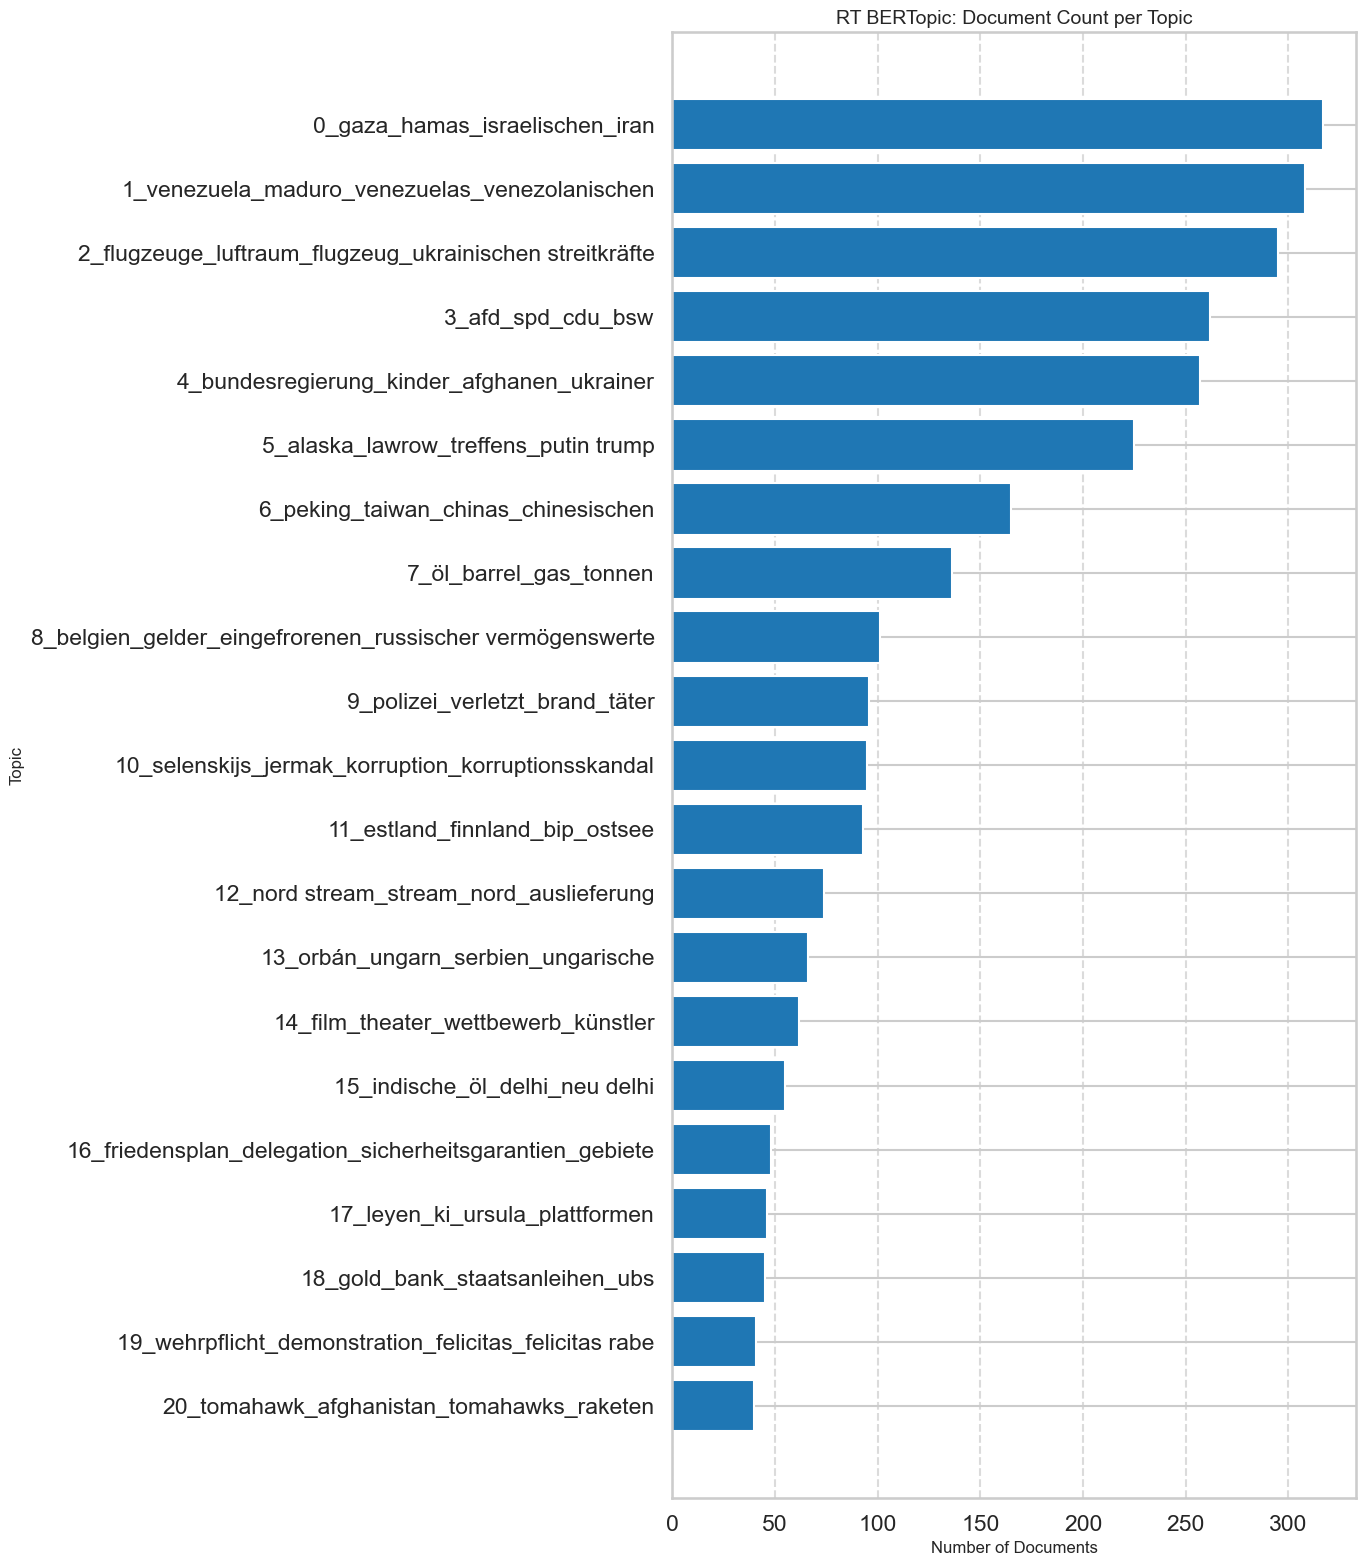

In [ ]:
fig, ax = plt.subplots(figsize=(14, 16))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('RT BERTopic: Document Count per Topic', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
# Prepare data for topics over time
prepared_dates = pd.to_datetime(result["prepared_documents"]["Date"], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()
docs_for_time = [doc for doc, ok in zip(result["docs"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('RT: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
